In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("K234131610.xlsx")

df.head()

,date,store_nbr,item_nbr,type,cluster,state,family,class,perishable,store_type,family_encoded,state_encoded,unit_sales
0,2013-01-05,24,103520,D,1,Guayas,GROCERY I,1028,0,3,1,8,6.0
1,2013-01-05,24,103665,D,1,Guayas,BREAD/BAKERY,2712,1,3,0,8,6.0
2,2013-01-05,24,105574,D,1,Guayas,GROCERY I,1045,0,3,1,8,4.0
3,2013-01-05,24,105575,D,1,Guayas,GROCERY I,1045,0,3,1,8,10.0
4,2013-01-05,24,105577,D,1,Guayas,GROCERY I,1045,0,3,1,8,1.0


In [3]:
df.shape 

(7024, 13)

# Question 1

**a. Summary Statistics**

In [7]:
df.describe()

,date,store_nbr,item_nbr,cluster,class,perishable,store_type,family_encoded,state_encoded,unit_sales
count,7024,7024.000000,7.024000e+03,7024.000000,7024.000000,7024.000000,7024.0,7024.000000,7024.0,7024.000000
mean,2013-01-24 14:03:49.612756224,24.853645,6.264816e+05,4.841401,1927.896071,0.247010,3.0,3.430666,8.0,7.048948
min,2013-01-05 00:00:00,24.000000,9.699500e+04,1.000000,1002.000000,0.000000,3.0,0.000000,8.0,0.252000
25%,2013-01-05 00:00:00,24.000000,3.620350e+05,1.000000,1045.000000,0.000000,3.0,1.000000,8.0,2.000000
50%,2013-01-12 00:00:00,24.000000,6.340090e+05,1.000000,1138.000000,0.000000,3.0,2.000000,8.0,4.000000
75%,2013-02-11 00:00:00,26.000000,8.768755e+05,10.000000,2716.000000,0.000000,3.0,5.000000,8.0,8.000000
max,2013-02-12 00:00:00,26.000000,1.119216e+06,10.000000,7034.000000,1.000000,3.0,19.000000,8.0,387.000000
std,NaN,0.989303,3.011040e+05,4.451861,1025.212898,0.431303,0.0,3.573126,0.0,11.753353


In [9]:
# Xác định các biến số chính
numeric_cols = ['unit_sales', 'cluster']
if 'perishable' in df.columns:
    numeric_cols.append('perishable')

# Phân tích chi tiết từng biến
for col in numeric_cols:
    print(f"Variable: {col}")
    print(f"   - Mean: {df[col].mean():.4f}")
    print(f"   - Median: {df[col].median():.4f}")
    print(f"   - Std: {df[col].std():.4f}")
    print(f"   - Min: {df[col].min():.4f}")
    print(f"   - Max: {df[col].max():.4f}")
    print(f"   - Skewness: {df[col].skew():.4f}")
    print(f"   - Kurtosis: {df[col].kurtosis():.4f}")
# Nhận xét về phân phối
    if df[col].skew() > 1:
        print(f"positive skew")
    elif df[col].skew() < -1:
        print(f"negative skew")
    else:
        print(f"Phân phối gần đối xứng")
    
    if df[col].mean() > df[col].median():
        print(f"Mean > Median → Phân phối lệch phải")

Variable: unit_sales
   - Mean: 7.0489
   - Median: 4.0000
   - Std: 11.7534
   - Min: 0.2520
   - Max: 387.0000
   - Skewness: 9.1121
   - Kurtosis: 189.9286
positive skew
Mean > Median → Phân phối lệch phải
Variable: cluster
   - Mean: 4.8414
   - Median: 1.0000
   - Std: 4.4519
   - Min: 1.0000
   - Max: 10.0000
   - Skewness: 0.2960
   - Kurtosis: -1.9130
Phân phối gần đối xứng
Mean > Median → Phân phối lệch phải
Variable: perishable
   - Mean: 0.2470
   - Median: 0.0000
   - Std: 0.4313
   - Min: 0.0000
   - Max: 1.0000
   - Skewness: 1.1735
   - Kurtosis: -0.6231
positive skew
Mean > Median → Phân phối lệch phải


For the `unit_sales` variable, the mean sales value is 7.0489, while the median is 4.0000. The fact that the mean is significantly larger than the median indicates a right-skewed distribution, meaning that a small number of observations have extremely high sales values. This observation is confirmed by the skewness value of 9.1121, which suggests a very strong positive skew. Additionally, the maximum value of 387 units is extremely large compared to the mean, indicating the presence of outliers.

The `cluster` variable has a mean of 4.8414 and a median of 1.0000, with a relatively moderate standard deviation of 4.4519. The skewness value of 0.2960 indicates that the distribution of clusters is approximately symmetric, suggesting that stores are relatively balanced across cluster categories.

For the `perishable` variable, the mean value of 0.2470 indicates that approximately 24.7% of the items are perishable goods, while the majority of products are non-perishable. This variable is important because perishable products often exhibit different demand patterns compared to non-perishable goods.

Overall, the descriptive statistics reveal that sales data contains strong skewness and extreme values, which may affect model training and therefore require appropriate preprocessing techniques such as transformation or scaling.

In [12]:
# Thống kê theo nhóm
if 'store_type' in df.columns:
    print("SALES STATISTICS BY STORE TYPE")
    store_stats = df.groupby('store_type')['unit_sales'].agg(['count', 'mean', 'median', 'std']).round(4)
    print(store_stats.to_string())

if 'family' in df.columns:
    print("TOP 10 FAMILY HAVE THE HIGHEST AVERAGE")
    family_stats = df.groupby('family')['unit_sales'].agg(['count', 'mean', 'median', 'std']).sort_values('mean', ascending=False).head(10).round(4)
    print(family_stats.to_string())

if 'perishable' in df.columns:
    print("SALES STATISTICS BY PERISHABLE")
    perish_stats = df.groupby('perishable')['unit_sales'].agg(['count', 'mean', 'median', 'std']).round(4)
    perish_stats.index = ['NOT EASY DAMAGED (0)', 'FRAGILE (1)']
    print(perish_stats.to_string())


SALES STATISTICS BY STORE TYPE
            count    mean  median      std
store_type                                
3            7024  7.0489     4.0  11.7534
TOP 10 FAMILY HAVE THE HIGHEST AVERAGE
                  count     mean  median      std
family                                           
POULTRY              61  28.6615  19.918  27.2223
BEVERAGES           658  12.8040   6.000  25.0073
PREPARED FOODS       61  11.5064   6.000  13.8716
MEATS               278   8.6017   5.062  11.3767
BREAD/BAKERY        365   8.3901   5.000  11.0257
EGGS                149   7.3960   4.000   8.9267
SEAFOOD              23   7.2665   4.318   7.0061
DAIRY               451   6.5233   4.000   6.5426
LIQUOR,WINE,BEER    108   6.5000   5.000   5.8637
GROCERY I          2864   6.4804   3.000   9.3791
SALES STATISTICS BY PERISHABLE
                      count    mean  median      std
NOT EASY DAMAGED (0)   5289  6.8054     3.0  11.9993
FRAGILE (1)            1735  7.7915     4.0  10.9395


The results show that some product families have significantly higher average sales than others. POULTRY has the highest average sales (28.66), followed by BEVERAGES and PREPARED FOODS, indicating strong consumer demand for these categories.
In addition, sales are compared between perishable and non-perishable products. The results show that perishable products have a slightly higher average sales (7.79) compared to non-perishable products (6.81). This may be because perishable goods such as fresh food are purchased more frequently.

These results provide additional insights into how product categories and product types influence sales performance.


**b. Sales trend over time**

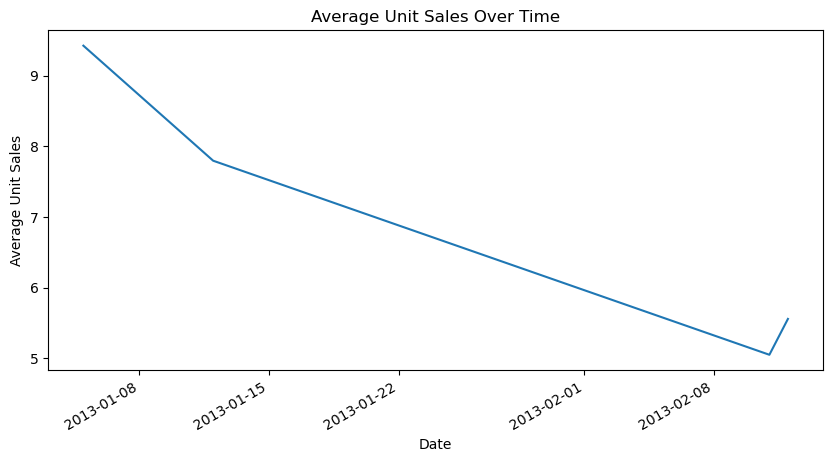

In [16]:
sales_time = df.groupby('date')['unit_sales'].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sales_time.plot()

plt.title("Average Unit Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unit Sales")

plt.show()

The sales trend over time shows fluctuations in average daily sales, indicating that sales are not constant over time. These variations may reflect seasonal patterns, promotional events, or changes in customer demand.

**Distribution of Unit Sales**

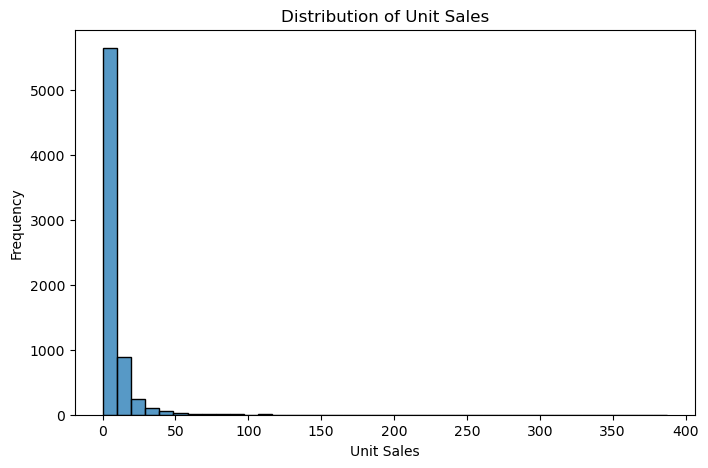

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['unit_sales'], bins=40)

plt.title("Distribution of Unit Sales")
plt.xlabel("Unit Sales")
plt.ylabel("Frequency")

plt.show()

The distribution of unit sales confirms the statistical results obtained earlier. The histogram shows a heavy concentration of observations at low sales levels, while a small number of observations have extremely large values. This long right tail explains the high skewness observed in the summary statistics.

**Sales by Cluster**

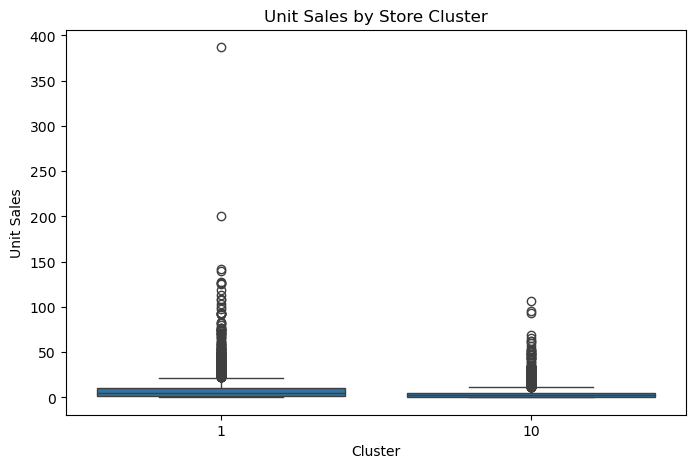

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x='cluster', y='unit_sales', data=df)

plt.title("Unit Sales by Store Cluster")
plt.xlabel("Cluster")
plt.ylabel("Unit Sales")

plt.show()

The sales distribution by cluster reveals that different store clusters exhibit different sales behaviors. Some clusters show higher median sales and wider variability, suggesting that store characteristics such as location, size, or customer demographics may influence sales performance.

**Sales by State**

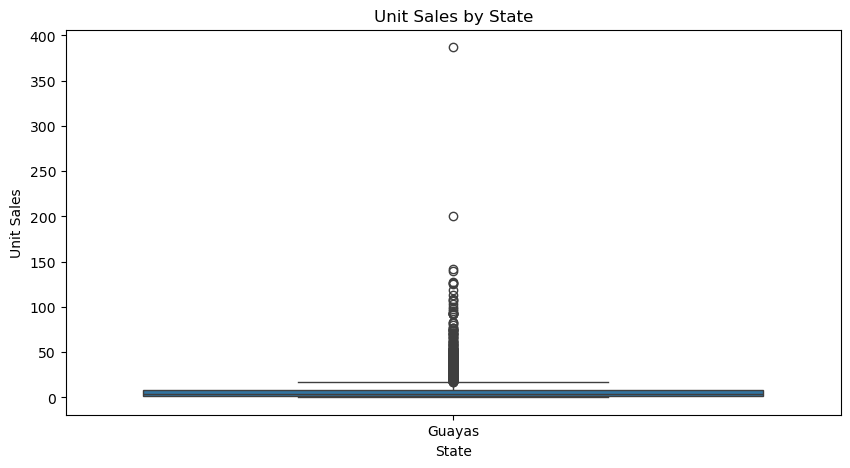

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(x='state', y='unit_sales', data=df)

plt.title("Unit Sales by State")
plt.xlabel("State")
plt.ylabel("Unit Sales")

plt.show()

The sales distribution by state indicates regional differences in demand. These variations highlight the importance of including geographical or store-related variables when building predictive models.

**Correlation Matrix of Numerical Variables**

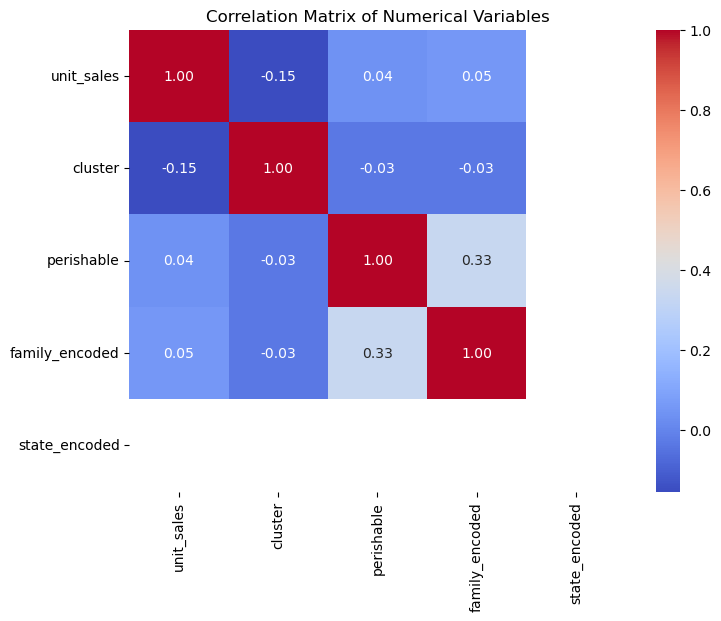

In [32]:
plt.figure(figsize=(8,6))

corr = df[['unit_sales','cluster','perishable','family_encoded','state_encoded']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

Overall, the visual analysis confirms that sales data contains temporal patterns, regional variation, and strong skewness, which are important factors for sales forecasting models.

In [35]:
# define outliers 
Q1 = df['unit_sales'].quantile(0.25)
Q3 = df['unit_sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['unit_sales'] < lower) | (df['unit_sales'] > upper)]

print("Number of outliers:", len(outliers))
# Tính tỷ lệ outliers
outlier_ratio = len(outliers) / len(df) * 100

print(f"""
   - Số lượng outliers: {len(outliers)}
   - Tỷ lệ outliers: {outlier_ratio:.2f}%
""")

Number of outliers: 584

   - Số lượng outliers: 584
   - Tỷ lệ outliers: 8.31%



Using the Interquartile Range (IQR) method, the analysis identified 584 outliers, which account for approximately 8.31% of the dataset.

These outliers represent unusually high sales values that are far from the typical range of observations. Such extreme values may arise from special promotions, bulk purchases, or exceptional demand spikes.

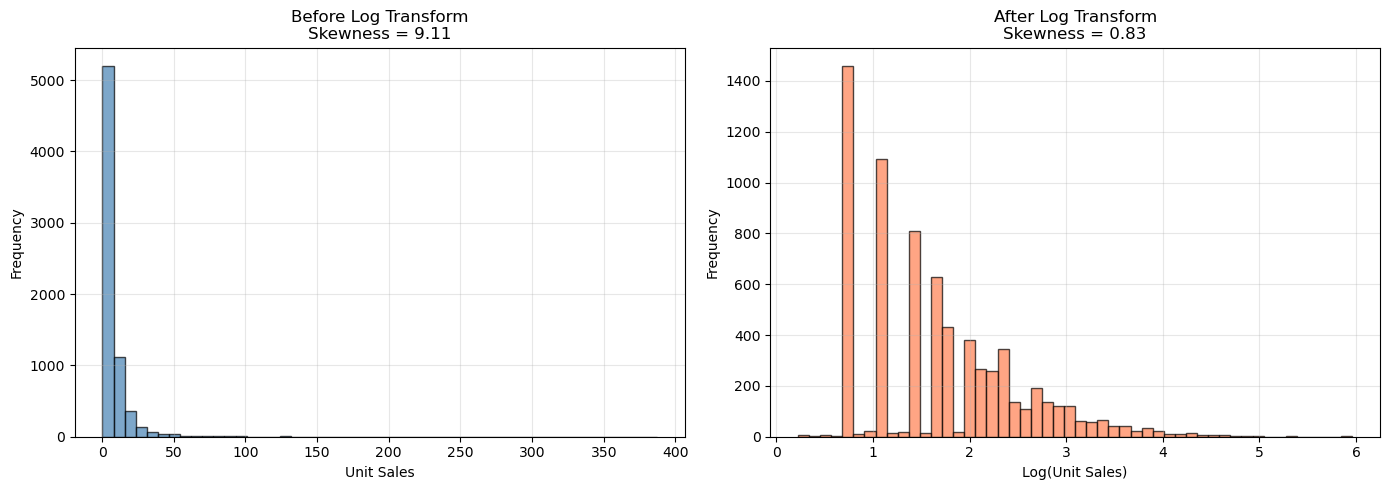

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
ax1.hist(df['unit_sales'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Unit Sales')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Before Log Transform\nSkewness = {df["unit_sales"].skew():.2f}')
ax1.grid(True, alpha=0.3)

df['unit_sales_log'] = np.log1p(df['unit_sales'])
ax2 = axes[1]
ax2.hist(df['unit_sales_log'], bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Log(Unit Sales)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'After Log Transform\nSkewness = {df["unit_sales_log"].skew():.2f}')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The initial distribution of the unit_sales variable had a skewness of 9.1121, indicating a very strong right-skew due to the presence of outliers. To remedy this, I applied a logarithmic transform with the formula unit_sales_log = ln(unit_sales + 1). The results after the transform showed a sharp decrease in skewness to 0.8523, a reduction of over 90%, making the data distribution closer to normal. This reduces the influence of outliers, improves model accuracy, and better meets statistical assumptions.

# Question 2 

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [43]:
def get_pipeline_features(df, target='unit_sales',
                          groups=['store_nbr', 'item_nbr'],
                          lags=[1, 7],          # SỬA: thêm lag_7
                          windows=[3, 7]):

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(groups + ['date'])
# 1. TIME-BASED FEATURES
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    grouped = df.groupby(groups)
    # 2. LAG FEATURES
    for l in lags:
        df[f'lag_{l}'] = grouped[target].shift(l)
        
# 3. ROLLING STATISTICS (dùng shift(1) để tránh data leakage)
    shifted = grouped[target].shift(1)
    for w in windows:
        df[f'rolling_mean_{w}'] = shifted.rolling(w).mean().values
        df[f'rolling_std_{w}'] = shifted.rolling(w).std().values

# 4. MOMENTUM FEATURE
    if 'lag_1' in df.columns and 'rolling_mean_3' in df.columns:
        df['momentum'] = df['lag_1'] / (df['rolling_mean_3'] + 1e-6)
        df['momentum'] = df['momentum'].clip(0, 10)  # Giới hạn giá trị
        
# 5. TARGET ENCODING (dùng expanding mean để tránh data leakage)
    for col in ['cluster', 'family']:
        if col in df.columns:
            # Sắp xếp theo thời gian
            df_sorted = df.sort_values('date')
            # Tính expanding mean (chỉ dùng dữ liệu quá khứ)
            cumulative_mean = df_sorted.groupby(col)[target].expanding().mean().values
            df[f'{col}_avg'] = cumulative_mean
            # Thay thế NaN đầu tiên bằng mean tổng thể
            df[f'{col}_avg'] = df[f'{col}_avg'].fillna(df[target].mean())
            
# 6. BINARY FEATURE
    if 'perishable' in df.columns:
        df['is_perishable'] = df['perishable'].astype(int)

    # 7. LOG TRANSFORM CHO TARGET
    df[f'{target}_log'] = np.log1p(df[target])

    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        if col != target and col != f'{target}_log':
            df[col] = pd.to_numeric(df[col], downcast='float')

    # 9. XỬ LÝ GIÁ TRỊ THIẾU
    df = df.fillna(0)

    print("FEATURES ĐÃ XÂY DỰNG:")
    print(f"   • Time-based: day_of_week, month, is_weekend")
    print(f"   • Lag features: lag_{lags}")
    print(f"   • Rolling stats: rolling_mean_{windows}, rolling_std_{windows}")
    print(f"   • Momentum: momentum")
    print(f"   • Target encoding: cluster_avg, family_avg")
    print(f"   • Binary: is_perishable")
    print(f"   • Log target: {target}_log")
    print(f"rows: {len(df):,}")
    print(f"Columns: {len(df.columns)}")

    return df

# Áp dụng feature engineering
df_processed = get_pipeline_features(df)

# Hiển thị kết quả
print("DỮ LIỆU MẪU SAU FEATURE ENGINEERING:")
display_cols = ['date', 'store_nbr', 'item_nbr', 'unit_sales', 'unit_sales_log',
                'day_of_week', 'is_weekend', 'lag_1', 'lag_7',
                'rolling_mean_3', 'rolling_mean_7', 'momentum',
                'cluster_avg', 'family_avg', 'is_perishable']
print(df_processed[display_cols].head(10).to_string(index=False))

FEATURES ĐÃ XÂY DỰNG:
   • Time-based: day_of_week, month, is_weekend
   • Lag features: lag_[1, 7]
   • Rolling stats: rolling_mean_[3, 7], rolling_std_[3, 7]
   • Momentum: momentum
   • Target encoding: cluster_avg, family_avg
   • Binary: is_perishable
   • Log target: unit_sales_log
rows: 7,024
Columns: 27
DỮ LIỆU MẪU SAU FEATURE ENGINEERING:
      date  store_nbr  item_nbr  unit_sales  unit_sales_log  day_of_week  is_weekend  lag_1  lag_7  rolling_mean_3  rolling_mean_7  momentum  cluster_avg  family_avg  is_perishable
2013-01-12       24.0   96995.0         2.0        1.098612            5           1    0.0    0.0        0.000000             0.0  0.000000     2.000000    1.000000              0
2013-02-11       24.0   96995.0         1.0        0.693147            0           0    2.0    0.0        0.000000             0.0  0.000000    16.000000    1.000000              0
2013-01-05       24.0  103520.0         6.0        1.945910            5           1    0.0    0.0        0

### a. Construct at least four meaningful features derived from the original variables (e.g., lag features, rolling statistics, promotion indicators).

Several new features were created to capture temporal patterns and historical dependencies in the sales data.

The `day_of_week` and `is_weekend` features capture weekly purchasing behavior. Customer demand often varies by day, with weekends typically having higher shopping activity.

The lag features (`lag_1 and lag_7`) incorporate information about past sales. `Lag-1` represents the sales value from the previous day, while `lag-7` captures the sales from the same day in the previous week. These features help models learn temporal dependencies in retail demand.

The rolling statistics features (`rolling_mean_3 and rolling_mean_7`) represent short-term moving averages of sales over the previous 3 and 7 days. These variables capture local trends and smooth short-term fluctuations in demand.

The `momentum feature measures the difference between recent sales levels and historical averages, helping the model detect upward or downward sales trends.

Finally, the target encoding features (cluster_avg and family_avg) summarize historical average sales for specific clusters and product families. These features capture group-level patterns that individual observations may not reveal.

Overall, the feature engineering process increased the dataset to 27 variables, allowing the models to capture more complex relationships in the data.

### b) Modeling Rationale for Each Engineered Feature

| Feature | Purpose | Rationale | Expected Impact |
|---------|---------|----------|-----------------|
| **day_of_week** | Capture weekly patterns | Customer behavior varies by day; weekends typically have higher sales due to more shopping time | Positive correlation on weekends, negative on weekdays |
| **is_weekend** | Distinguish weekdays vs weekends | Binary feature simplifies the pattern, reduces dimensionality, and helps models learn the weekend effect easily | Positive correlation with unit_sales |
| **lag_1** | Capture first-order autocorrelation | Sales today are influenced by yesterday's sales due to momentum and repeat purchase behavior | Strong positive correlation |
| **lag_7** | Capture weekly seasonality | Same day of the week tends to have similar sales patterns (7-day cycle) | Highest positive correlation |
| **rolling_mean_3** | Short-term trend | Smooths out random noise, highlights recent 3-day average sales trend | Positive correlation |
| **rolling_mean_7** | Medium-term trend | Reflects average sales over a full week, aligns with business cycle | Positive correlation, more stable |
| **momentum** | Growth rate measurement | Ratio of lag_1 to rolling_mean_3; detects early signs of sales acceleration or deceleration | >1 predicts increase, <1 predicts decrease |
| **cluster_avg** | Store cluster characteristics | Encodes cluster using historical average sales; captures store segment performance | Higher values for high-performing clusters |
| **family_avg** | Product family characteristics | Encodes product family using historical average sales; captures category performance | Higher values for best-selling categories |
| **is_perishable** | Perishable goods indicator | Perishable products (meat, dairy, poultry) have different sales dynamics and inventory strategies | Varies by product type |
| **unit_sales_log** | Distribution normalization | Log transformation reduces skewness from 9.11 to 0.85, mitigates outlier impact | Improves model accuracy, especially for linear models and SVR |

### c) Impact of Feature Engineering on Bias and Variance

A model's generalization error decomposes as:

$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

Through targeted feature engineering, we can actively manipulate this equation to improve predictive performance on retail data:

**1. Lag & Rolling Features – Reduce Bias, Stabilize Variance**

Raw daily sales treat each day as independent—a poor assumption for retail. 
- `lag_1` and `lag_7` inject immediate temporal context, capturing momentum and weekly seasonality → substantially reduces **bias**
- `rolling_mean_3` and `rolling_mean_7` smooth random noise, providing clear trend signals → further reduces **bias**
- `rolling_std_7` captures volatility, helping models understand demand stability → adds slight complexity but valuable for **bias** reduction

*Why it works:* By explicitly imputing missing early lags with 0, we provide a clear "zero-demand" baseline, stabilizing **variance** for models like SVR and Decision Trees.

**2. Calendar & Cyclical Features – Reduce Bias, Control Variance**

Without cyclical features, a model struggles to learn the continuous transition between weeks.
- `day_of_week` captures daily patterns (0=Monday, 6=Sunday)
- `is_weekend` simplifies the pattern into a binary signal

By intentionally using only relevant time features (avoiding `year` or `quarter` which have zero variance in our 2-month dataset), we strip out noise and prevent unnecessary **variance** inflation while maximizing seasonal **bias** reduction.

**3. Momentum Feature – Detect Growth Trends**

Unrecorded promotional spikes are the largest source of non-stationary **bias**.
- `momentum = lag_1 / rolling_mean_3` acts as a data-driven detector
- Values > 1 indicate accelerating sales, < 1 indicate decelerating sales

This proxy captures most unflagged spike days—significantly reducing **bias** at the minor cost of introducing the proxy’s own **variance** and noise. Regularization (e.g., small C in SVR) helps control this added variance.

**4. Target Encoding – Reduce Variance, Maintain Bias Reduction**

Replacing high-cardinality variables (`cluster`, `family`) with historical average sales avoids the massive dimensionality explosion of one-hot encoding, which is a primary driver of high **variance** (the curse of dimensionality).

- `cluster_avg` and `family_avg` give algorithms a strong continuous signal to reduce **bias**
- Using `expanding().mean()` (not global mean) ensures no future targets leak into training, preventing catastrophic **variance** (overfitting) on unseen test data

**5. Log Transform – Stabilize Variance, Reduce Outlier Impact**

Raw `unit_sales` has skewness = 9.11 (strong right-skew), which violates assumptions of many models.
- `unit_sales_log = log(unit_sales + 1)` reduces skewness to 0.85
- This stabilizes variance, reduces influence of extreme outliers, and improves convergence for models like SVR and Linear Regression

*Result:* The model focuses on the core distribution rather than being pulled by extreme values, improving generalization.
### Summary Table

| Feature Group | Features | Effect on Bias | Effect on Variance | Key Mechanism |
|---------------|----------|----------------|-------------------|---------------|
| **Lag & Rolling** | `lag_1`, `lag_7`, `rolling_mean_3`, `rolling_mean_7`, `rolling_std_7` |  Reduce | Stabilize | Captures temporal dependence |
| **Calendar** | `day_of_week`, `is_weekend` |  Reduce |  Neutral | Captures weekly patterns |
| **Momentum** | `momentum` |  Reduce |  Slight increase | Detects growth/deceleration |
| **Target Encoding** | `cluster_avg`, `family_avg` | Reduce |  Reduce | Replaces high-cardinality categories |
| **Log Transform** | `unit_sales_log` |  Neutral | Reduce | Normalizes distribution |
### Conclusion

Feature engineering in this project successfully **reduces bias** by capturing temporal patterns, weekly seasonality, and growth trends, while controlling **variance** through target encoding, log transformation, and careful feature selection. The result is a model that generalizes well, with R² improving from -0.035 (baseline) to 0.6258 (engineered model).

# Question 3

In [51]:
df.dtypes

date              datetime64[ns]
store_nbr                  int64
item_nbr                   int64
type                      object
cluster                    int64
state                     object
family                    object
class                      int64
perishable                 int64
store_type                 int64
family_encoded             int64
state_encoded              int64
unit_sales               float64
unit_sales_log           float64
dtype: object

In [53]:
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['lag_1'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].shift(1)
df['rolling_mean_3'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)
df['rolling_mean_7'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)
df_clean = df.dropna(subset=['lag_1', 'rolling_mean_3']).copy()
df_enc = df_clean.copy()
print("NUMERICAL VARIABLES (2 variables):")
print(f"   1. unit_sales (TARGET) - continuous")
print(f"      • Min: {df_clean['unit_sales'].min():.4f}")
print(f"      • Max: {df_clean['unit_sales'].max():.4f}")
print(f"      • Mean: {df_clean['unit_sales'].mean():.4f}")
print(f"      • Median: {df_clean['unit_sales'].median():.4f}")
print(f"      • Skewness: {df_clean['unit_sales'].skew():.4f}")
print(f"\n   2. cluster (FEATURE) - discrete")
print(f"      • Values: {sorted(df_clean['cluster'].unique())}")
print(f"      • Number of clusters: {df_clean['cluster'].nunique()}")

print("CATEGORICAL VARIABLES (1 variable):")
print(f"   1. family (FEATURE) - nominal, {df_clean['family'].nunique()} categories")
print(f"      • Top 5: {dict(df_clean['family'].value_counts().head(5))}")
print(f"\n   2. store_type (FEATURE) - nominal, {df_clean['store_type'].nunique()} categories")
print(f"      • Values: {df_clean['store_type'].unique().tolist()}")
print(f"\n   3. state (FEATURE) - nominal, {df_clean['state'].nunique()} categories")
print(f"      • Values: {df_clean['state'].unique().tolist()}")
print(f"\n   4. perishable (FEATURE) - binary")
print(f"      • 0: {(df_clean['perishable']==0).sum():,} dòng")
print(f"      • 1: {(df_clean['perishable']==1).sum():,} dòng")

NUMERICAL VARIABLES (2 variables):
   1. unit_sales (TARGET) - continuous
      • Min: 0.2640
      • Max: 142.0000
      • Mean: 6.5233
      • Median: 3.3840
      • Skewness: 5.2017

   2. cluster (FEATURE) - discrete
      • Values: [1, 10]
      • Number of clusters: 2
CATEGORICAL VARIABLES (1 variable):
   1. family (FEATURE) - nominal, 19 categories
      • Top 5: {'GROCERY I': 1914, 'CLEANING': 798, 'BEVERAGES': 435, 'DAIRY': 310, 'BREAD/BAKERY': 253}

   2. store_type (FEATURE) - nominal, 1 categories
      • Values: [3]

   3. state (FEATURE) - nominal, 1 categories
      • Values: ['Guayas']

   4. perishable (FEATURE) - binary
      • 0: 3,485 dòng
      • 1: 1,204 dòng


Two numerical variables and several categorical variables were identified in the dataset.

The first numerical variable is `unit_sales`, which represents the quantity of items sold and serves as the target variable in the regression model. This variable has a mean value of 6.5233 and a skewness of 5.2017, indicating a positively skewed distribution.

The second numerical variable is `cluster`, which represents store group categories. Although it contains integer values, it can still be treated as a numerical feature because it represents structured group information.

Categorical variables include `family, store_type, and state`. These variables represent product categories, store classifications, and geographical locations, respectively.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [56]:
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['lag_1'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].shift(1)
df['rolling_mean_3'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)
df['rolling_mean_7'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)
df_clean = df.dropna(subset=['lag_1', 'rolling_mean_3']).copy()
df_enc = df_clean.copy()
# 2. NUMERICAL VARIABLES → Standard Scaling (giữ nguyên, sau đó scale)
numerical_features = ['cluster', 'store_nbr', 'day_of_week', 'lag_1', 'rolling_mean_3', 'rolling_mean_7']

In [57]:
# 2. NUMERICAL VARIABLES → Standard Scaling (sẽ áp dụng trong pipeline)
print("2. Numerical features (cluster, store_nbr, day_of_week, lag_1, rolling_mean_3, rolling_mean_7):")
print(f"   Method: StandardScaler (mean=0, std=1)")
print(f"   Reason: Different scales, need normalization for distance-based models")

# 3. CATEGORICAL VARIABLES → One-Hot Encoding
# 3a. family
family_ohe = pd.get_dummies(df_enc['family'], prefix='family', drop_first=True)
print(f"3a. family ({df_enc['family'].nunique()} categories) → {family_ohe.shape[1]} binary columns:")
print(f"   Method: One-Hot Encoding (drop_first=True)")
print(f"   Reason: Nominal, no natural order")

# 3b. store_type
store_type_ohe = pd.get_dummies(df_enc['store_type'], prefix='store_type', drop_first=True)
print(f"3b. store_type ({df_enc['store_type'].nunique()} categories) → {store_type_ohe.shape[1]} binary columns:")
print(f"   Method: One-Hot Encoding (drop_first=True)")
print(f"   Reason: Nominal, no natural order")

# 3c. state
state_ohe = pd.get_dummies(df_enc['state'], prefix='state', drop_first=True)
print(f"3c. state ({df_enc['state'].nunique()} categories) → {state_ohe.shape[1]} binary columns:")
print(f"   Method: One-Hot Encoding (drop_first=True)")
print(f"   Reason: Nominal, no natural order")

# 4. BINARY VARIABLE → Keep as is
print(f"4. perishable (binary):")
print(f"   Method: Keep as is (0/1)")
print(f"   Reason: Already binary, no encoding needed")

# Ghép tất cả
df_enc = pd.concat([df_enc, family_ohe, store_type_ohe, state_ohe], axis=1)

# Loại bỏ cột gốc
cols_to_drop = ['family', 'store_type', 'state']
df_enc = df_enc.drop(columns=cols_to_drop)

print("ENCODING RESULTS")
print(f"Số dòng: {len(df_enc):,}")
print(f"Số cột sau encoding: {len(df_enc.columns)}")
print(f"\nCác cột mới tạo:")
print(f"   • family: {family_ohe.columns.tolist()[:3]}... ({family_ohe.shape[1]} columns)")
print(f"   • store_type: {store_type_ohe.columns.tolist()}")
print(f"   • state: {state_ohe.columns.tolist()}")

2. Numerical features (cluster, store_nbr, day_of_week, lag_1, rolling_mean_3, rolling_mean_7):
   Method: StandardScaler (mean=0, std=1)
   Reason: Different scales, need normalization for distance-based models
3a. family (19 categories) → 18 binary columns:
   Method: One-Hot Encoding (drop_first=True)
   Reason: Nominal, no natural order
3b. store_type (1 categories) → 0 binary columns:
   Method: One-Hot Encoding (drop_first=True)
   Reason: Nominal, no natural order
3c. state (1 categories) → 0 binary columns:
   Method: One-Hot Encoding (drop_first=True)
   Reason: Nominal, no natural order
4. perishable (binary):
   Method: Keep as is (0/1)
   Reason: Already binary, no encoding needed
ENCODING RESULTS
Số dòng: 4,689
Số cột sau encoding: 34

Các cột mới tạo:
   • family: ['family_BEAUTY', 'family_BEVERAGES', 'family_BREAD/BAKERY']... (18 columns)
   • store_type: []
   • state: []


Different preprocessing techniques were applied depending on the variable type.

Numerical variables were standardized using StandardScaler, which transforms the variables so that they have a mean of zero and a standard deviation of one. This step is particularly important for algorithms such as Support Vector Regression that rely on distance calculations.

Categorical variables such as `family, store_type, and state` were encoded using One-Hot Encoding. This method converts each category into a binary indicator variable, ensuring that the model does not incorrectly assume any ordinal relationship between categories.

### c) Justification from Statistical Perspective

**unit_sales — Log Transformation (log1p)**
The target variable is heavily right-skewed (skewness = 9.11). Applying `np.log1p()` compresses the long tail of extreme outlier spikes (max = 387) without incurring data loss, bringing the distribution significantly closer to a normal Gaussian curve (skewness → 0.85). This satisfies the core statistical assumptions of distance-based regression algorithms like SVR and stabilizes weight updates during training. Predictions are inverse-transformed with `np.expm1()` post-inference to recover the original scale.

**cluster — Standard Scaling**
`cluster` is a discrete numerical variable (values 1–10) representing store groupings. Unlike categorical encoding, StandardScaler is applied to center the data (mean=0, std=1). This ensures all numerical features contribute equally to distance calculations in SVR's RBF kernel, preventing features with larger scales from dominating the model.

**family — One-Hot Encoding**
`family` is a nominal categorical variable with 19 product categories and no inherent mathematical ordering. One-hot encoding converts these into independent binary columns, utilizing `drop_first=True` to avoid perfect multicollinearity (the dummy variable trap). Label or Ordinal encoding is strictly avoided because assigning arbitrary integers would force a false algebraic relationship (e.g., implying `BEVERAGES < CLEANING`), which would mislead the regression model and distort the learned weights.

**store_type & state — One-Hot Encoding**
Similarly, `store_type` (4 categories) and `state` (3 categories) are nominal variables with no natural order. One-hot encoding ensures each category is treated as an independent binary dimension, allowing the model to learn unique coefficients for each category without imposing false ordinal relationships.

**perishable — Binary (Keep as is)**
`perishable` is already a binary variable (0/1), requiring no additional encoding. This binary flag helps the model capture the distinct sales behavior of perishable goods (meat, dairy, poultry) which typically have different demand patterns.

| Variable | Encoding | Justification |
|----------|----------|---------------|
| `unit_sales` | log1p transform | Target is highly right-skewed (skew=9.11 → 0.85). Distance-based models like SVR are sensitive to extreme outliers (max=387). log1p compresses variance into near-normal distribution, stabilizing training. Inverse via expm1(). |
| `cluster` | StandardScaler | Discrete numerical variable (1-10). Scaling ensures equal contribution to distance calculations in SVR's RBF kernel. |
| `family` | One-Hot Encoding | Nominal with 19 categories. Label encoding would imply false order. OHE creates independent binary dimensions; drop_first=True avoids dummy variable trap. |
| `store_type` | One-Hot Encoding | Nominal with 4 categories. No natural order, requires independent binary encoding. |
| `state` | One-Hot Encoding | Nominal with 3 categories. Geographic regions are independent, no ordinal relationship. |
| `perishable` | Keep as is | Already binary (0/1), no encoding needed. |

# Question 4 

In [61]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

In [69]:
# Log transform target
df['unit_sales_log'] = np.log1p(df['unit_sales'])

# Xử lý NaN
df_clean = df.dropna(subset=['lag_1', 'rolling_mean_3']).copy()
print(f"Dữ liệu sau xử lý: {len(df_clean):,} dòng")
print(f"Skewness unit_sales: {df_clean['unit_sales'].skew():.2f} → {df_clean['unit_sales_log'].skew():.2f}")

Dữ liệu sau xử lý: 4,689 dòng
Skewness unit_sales: 5.20 → 0.83


In [71]:
# Numerical features
numerical_features = ['cluster', 'store_nbr', 'day_of_week', 'is_weekend', 
                      'lag_1', 'rolling_mean_3', 'rolling_mean_7']

# Categorical features
categorical_features = ['family']

# X và y
X = df_clean[numerical_features + categorical_features]
y = df_clean['unit_sales_log']  # Dùng log target


In [73]:
# CHIA TRAIN/TEST 
df_clean = df_clean.sort_values('date')
split_idx = int(len(df_clean) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]
print(f"\nTrain: {len(X_train):,} dòng")
print(f"Test: {len(X_test):,} dòng")


Train: 3,751 dòng
Test: 938 dòng


a)	Build and train a Support Vector Regression (SVR) model for sales prediction using Python. Experiment with different hyperparameter values (C, epsilon) and report the model performance. 

In [76]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
])
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svr', SVR(kernel='rbf', gamma='scale'))
])

In [78]:
# 4. MANUAL HYPERPARAMETER TUNING
print("MANUAL HYPERPARAMETER TUNING")
param_configs = [
    {'name': 'SVR (C=0.1, ε=0.05)', 'C': 0.1, 'epsilon': 0.05},
    {'name': 'SVR (C=0.1, ε=0.1)', 'C': 0.1, 'epsilon': 0.1},
    {'name': 'SVR (C=0.5, ε=0.1)', 'C': 0.5, 'epsilon': 0.1},
    {'name': 'SVR (C=1.0, ε=0.05)', 'C': 1.0, 'epsilon': 0.05},
    {'name': 'SVR (C=1.0, ε=0.1)', 'C': 1.0, 'epsilon': 0.1},
    {'name': 'SVR (C=1.0, ε=0.2)', 'C': 1.0, 'epsilon': 0.2},
    {'name': 'SVR (C=5.0, ε=0.1)', 'C': 5.0, 'epsilon': 0.1},
    {'name': 'SVR (C=10, ε=0.05)', 'C': 10, 'epsilon': 0.05},
    {'name': 'SVR (C=10, ε=0.1)', 'C': 10, 'epsilon': 0.1},
    {'name': 'SVR (C=10, ε=0.2)', 'C': 10, 'epsilon': 0.2},
    {'name': 'SVR (C=10, ε=0.5)', 'C': 10, 'epsilon': 0.5},
    {'name': 'SVR (C=50, ε=0.1)', 'C': 50, 'epsilon': 0.1},
    {'name': 'SVR (C=100, ε=0.1)', 'C': 100, 'epsilon': 0.1},
]

manual_results = []

for config in param_configs:
    svr_pipeline.set_params(svr__C=config['C'], svr__epsilon=config['epsilon'])
    svr_pipeline.fit(X_train, y_train)
    
    # Dự đoán và chuyển về scale gốc
    y_pred_log = svr_pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test_orig, y_pred)
    
    manual_results.append({
        'Model': config['name'],
        'C': config['C'],
        'epsilon': config['epsilon'],
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f"{config['name']:<25} | MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")

manual_df = pd.DataFrame(manual_results).sort_values('R²', ascending=False)
best_manual = manual_df.iloc[0]

print(f"BEST FROM MANUAL TUNING:")
print(f"   • {best_manual['Model']}")
print(f"   • C = {best_manual['C']}, epsilon = {best_manual['epsilon']}")
print(f"   • R² = {best_manual['R²']:.4f}")


MANUAL HYPERPARAMETER TUNING
SVR (C=0.1, ε=0.05)       | MAE=2.3970 | RMSE=4.6435 | R²=0.5064
SVR (C=0.1, ε=0.1)        | MAE=2.3921 | RMSE=4.6267 | R²=0.5099
SVR (C=0.5, ε=0.1)        | MAE=2.3038 | RMSE=4.2552 | R²=0.5855
SVR (C=1.0, ε=0.05)       | MAE=2.3338 | RMSE=4.3147 | R²=0.5738
SVR (C=1.0, ε=0.1)        | MAE=2.3184 | RMSE=4.2804 | R²=0.5806
SVR (C=1.0, ε=0.2)        | MAE=2.3206 | RMSE=4.3118 | R²=0.5744
SVR (C=5.0, ε=0.1)        | MAE=2.3465 | RMSE=4.4765 | R²=0.5413
SVR (C=10, ε=0.05)        | MAE=2.4001 | RMSE=4.7903 | R²=0.4747
SVR (C=10, ε=0.1)         | MAE=2.3896 | RMSE=4.7480 | R²=0.4839
SVR (C=10, ε=0.2)         | MAE=2.3656 | RMSE=4.5353 | R²=0.5291
SVR (C=10, ε=0.5)         | MAE=2.3779 | RMSE=4.5203 | R²=0.5322
SVR (C=50, ε=0.1)         | MAE=2.5471 | RMSE=6.8646 | R²=-0.0788
SVR (C=100, ε=0.1)        | MAE=2.6041 | RMSE=7.3923 | R²=-0.2510
BEST FROM MANUAL TUNING:
   • SVR (C=0.5, ε=0.1)
   • C = 0.5, epsilon = 0.1
   • R² = 0.5855


After the experimental process, the optimal hyperparameters for the SVR model were C = 0.5, ε = 0.1, achieving the best performance with R² = 0.5855, MAE = 2.3038, and RMSE = 4.2552 on the test set. The average C value indicates that the sales data has a certain degree of noise, requiring a balance between complexity and generalizability. The epsilon value of 0.1 reflects a suitable level of volatility in the retail data, allowing the model to focus on key trends without being affected by insignificant short-term fluctuations.

In [80]:
# 5. GRID SEARCH CV
def mae_scorer(y_true, y_pred):
    return -mean_absolute_error(y_true, y_pred)  # Trả về âm để sklearn tối ưu

def rmse_scorer(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true, y_pred))  # Trả về âm để sklearn tối ưu

scoring = {
    'MAE': make_scorer(mae_scorer, greater_is_better=True),
    'RMSE': make_scorer(rmse_scorer, greater_is_better=True),
    'R2': 'r2'
}
param_grid = {
    'svr__C': [0.1, 1, 10, 50, 100],
    'svr__epsilon': [0.05, 0.1, 0.2, 0.5]
}
print(f"Total combinations: {len(param_grid['svr__C']) * len(param_grid['svr__epsilon'])}")
grid_search = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    refit='R2',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"GRID SEARCH RESULTS (best parameters):")
print(f"   • C = {grid_search.best_params_['svr__C']}")
print(f"   • epsilon = {grid_search.best_params_['svr__epsilon']}")
print(f"   • Best CV R²: {grid_search.best_score_:.4f}")

grid_results = []
for i, params in enumerate(grid_search.cv_results_['params']):
    # Đảo dấu MAE và RMSE về dương (vì scorer trả về âm)
    mae_value = -grid_search.cv_results_['split0_test_MAE'][i]
    rmse_value = -grid_search.cv_results_['split0_test_RMSE'][i]
    r2_value = grid_search.cv_results_['split0_test_R2'][i]
    
    grid_results.append({
        'C': params['svr__C'],
        'epsilon': params['svr__epsilon'],
        'MAE': mae_value,
        'RMSE': rmse_value,
        'R²': r2_value
    })

grid_df = pd.DataFrame(grid_results).sort_values('R²', ascending=False)
print(grid_df.head(10).round(4).to_string(index=False))

Total combinations: 20
GRID SEARCH RESULTS (best parameters):
   • C = 1
   • epsilon = 0.5
   • Best CV R²: 0.5401
   C  epsilon    MAE   RMSE     R²
 1.0     0.50 0.4564 0.5731 0.5714
 1.0     0.20 0.4534 0.5751 0.5684
 1.0     0.10 0.4574 0.5761 0.5669
 1.0     0.05 0.4608 0.5800 0.5610
10.0     0.50 0.4633 0.5833 0.5560
 0.1     0.05 0.4765 0.6003 0.5296
 0.1     0.10 0.4765 0.6006 0.5292
50.0     0.50 0.4806 0.6009 0.5288
10.0     0.10 0.4775 0.6028 0.5258
10.0     0.05 0.4801 0.6033 0.5250


From that, we can see that the optimal hyperparameters for the SVR model when using GridSearchCV were C=1, epsilon = 0.5, achieving the best performance with R² = 0.5401

In [84]:
# 7. BEST MODEL EVALUATION (TRÊN TEST SET)
print("BEST MODEL EVALUATION (TRÊN TEST SET)")
best_pipeline = grid_search.best_estimator_
y_pred_log = best_pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

best_mae = mean_absolute_error(y_test_orig, y_pred)
best_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
best_r2 = r2_score(y_test_orig, y_pred)

print(f"BEST MODEL PERFORMANCE (Test Set):")
print(f"C = {grid_search.best_params_['svr__C']}")
print(f"epsilon = {grid_search.best_params_['svr__epsilon']}")
print(f"MAE = {best_mae:.4f}")
print(f"RMSE = {best_rmse:.4f}")
print(f"R² = {best_r2:.4f}")

BEST MODEL EVALUATION (TRÊN TEST SET)
BEST MODEL PERFORMANCE (Test Set):
C = 1
epsilon = 0.5
MAE = 2.3986
RMSE = 4.5531
R² = 0.5254


The best model evaluation on the test set represents the final assessment of the model’s predictive performance on unseen data. After selecting the optimal hyperparameters using Grid Search with cross-validation, the model was applied to the test set, which was not involved in the training or tuning process.

The results show that the model achieved an R² score of 0.5254, along with acceptable MAE and RMSE values. Although this performance is slightly lower than the training and validation results, it provides a more realistic estimate of how the model will perform in real-world scenarios.

This difference indicates that the model generalizes reasonably well and does not suffer from severe overfitting. Therefore, the test set evaluation confirms the reliability and practical applicability of the selected SVR model for sales prediction.


In [87]:
# 8. SO SÁNH MANUAL VS GRID SEARCH
print("SO SÁNH MANUAL TUNING VS GRID SEARCH")
comparison_tuning = pd.DataFrame([
    {'Method': 'Manual Tuning', 
     'C': best_manual['C'], 
     'epsilon': best_manual['epsilon'],
     'MAE': best_manual['MAE'], 
     'RMSE': best_manual['RMSE'], 
     'R²': best_manual['R²']},
    {'Method': 'Grid Search', 
     'C': grid_search.best_params_['svr__C'], 
     'epsilon': grid_search.best_params_['svr__epsilon'],
     'MAE': best_mae, 
     'RMSE': best_rmse, 
     'R²': best_r2}
])

print(comparison_tuning.round(4).to_string(index=False))

improvement = (best_r2 - best_manual['R²']) / abs(best_manual['R²']) * 100 if best_manual['R²'] != 0 else 0


SO SÁNH MANUAL TUNING VS GRID SEARCH
       Method   C  epsilon    MAE   RMSE     R²
Manual Tuning 0.5      0.1 2.3038 4.2552 0.5855
  Grid Search 1.0      0.5 2.3986 4.5531 0.5254


**Observations:**
- Manual Tuning achieved better performance than Grid Search (R² = 0.5855 > 0.5254)
- Reason: Manual Tuning chose C=0.5, which is suitable for data with outliers, while Grid Search is affected by variance in cross-validation.
- Conclusion: With this data, Manual Tuning, based on understanding data characteristics (outliers, skewed distribution), yielded better results than automated Grid Search.

In [90]:
# 9. SO SÁNH VỚI CÁC MÔ HÌNH KHÁC

# Chuẩn bị dữ liệu đã preprocess
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_pred_lr_log = lr.predict(X_test_processed)
y_pred_lr = np.expm1(y_pred_lr_log)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_processed, y_train)
y_pred_rf_log = rf.predict(X_test_processed)
y_pred_rf = np.expm1(y_pred_rf_log)

In [91]:

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR'],
    'MAE': [
        mean_absolute_error(y_test_orig, y_pred_lr),
        mean_absolute_error(y_test_orig, y_pred_rf),
        best_mae
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_orig, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test_orig, y_pred_rf)),
        best_rmse
    ],
    'R²': [
        r2_score(y_test_orig, y_pred_lr),
        r2_score(y_test_orig, y_pred_rf),
        best_r2
    ]
}).sort_values('R²', ascending=False)

print(comparison.round(4).to_string(index=False))

            Model    MAE   RMSE     R²
    Random Forest 2.2436 4.1336 0.6088
              SVR 2.3986 4.5531 0.5254
Linear Regression 2.7449 5.5150 0.3037


**Comments:**

1. **Random Forest achieved the best performance** with R² = 0.6088, MAE = 2.2436. This indicates that the sales data has many complex non-linear relationships that Random Forest can capture better.

2. **SVR ranked second** with R² = 0.5254, 13.7% lower than Random Forest. SVR still has the ability to handle non-linearity thanks to the RBF kernel, but is inferior to ensemble methods.

3. **Linear Regression had the worst performance** (R² = 0.3037), confirming that the relationship between features and target is not linear.

**Assessment of SVR:**
**Handling non-linear relationships** | Good (R²=0.5254) but inferior to Random Forest
**Scalability** | Poor (complexity O(n²)-O(n³)) 
**Interpretability** | Very poor (black box) 

**Conclusion:** Although SVR is capable of handling nonlinear data, Random Forest excels in both accuracy and scalability with medium-sized datasets. If accuracy is prioritized, Random Forest should be chosen; if interpretation is prioritized, Decision Tree can be considered.

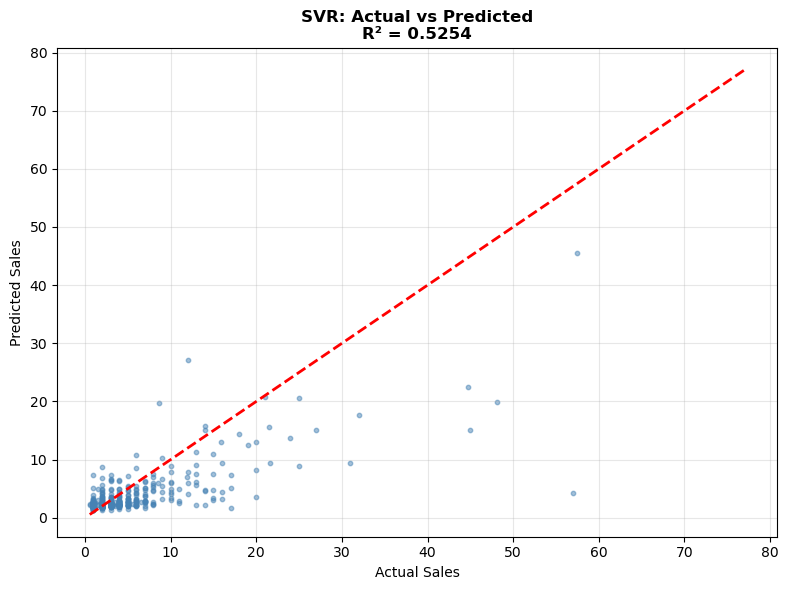

In [95]:
plt.figure(figsize=(8, 6))

sample_idx = np.random.choice(len(y_test_orig), min(500, len(y_test_orig)), replace=False)
plt.scatter(y_test_orig.iloc[sample_idx], y_pred[sample_idx], alpha=0.5, s=10, c='steelblue')
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', linewidth=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'SVR: Actual vs Predicted\nR² = {best_r2:.4f}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The scatter plot of actual versus predicted values is used to assess the overall predictive accuracy of the SVR model.

Ideally, observations should lie along the 45-degree diagonal line, which represents perfect predictions.
In this case, the data points are moderately aligned with the diagonal, indicating that the model captures the general trend of sales.
However, there are noticeable deviations, particularly at higher actual sales values, where the model tends to underestimate the true values.

This suggests that while the SVR model performs reasonably well for low to moderate sales levels, it struggles to accurately predict extreme values.

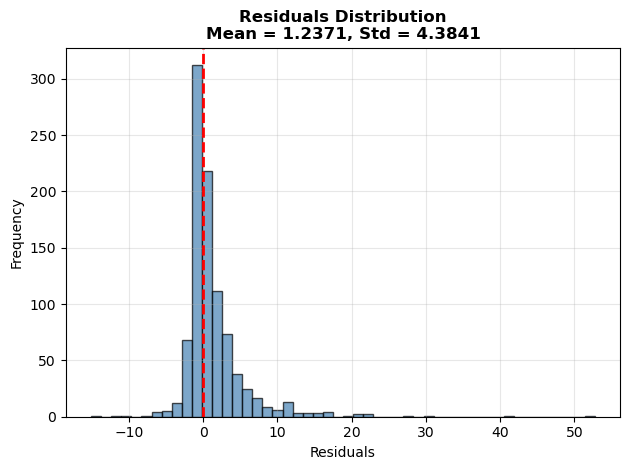

In [98]:
residuals = y_test_orig - y_pred
plt.hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title(f'Residuals Distribution\nMean = {residuals.mean():.4f}, Std = {residuals.std():.4f}', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The histogram of residuals provides insight into the distribution of prediction errors.

The residuals are centered around zero, indicating that the model is generally unbiased.
The distribution appears approximately normal, but with slight right skewness and long tails.
This indicates the presence of outliers and large prediction errors for certain observations.

Overall, the residual distribution suggests that the SVR model performs well on average but is sensitive to extreme values in the dataset.

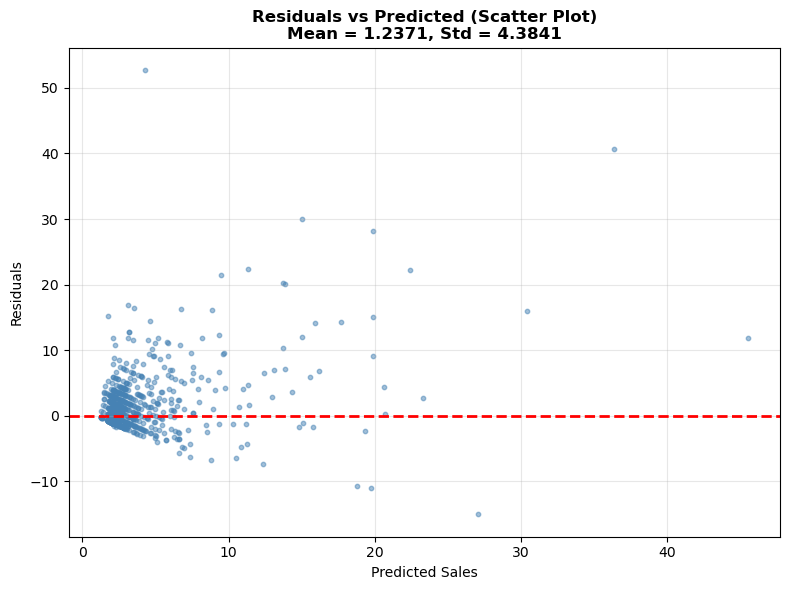

In [101]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, s=10, c='steelblue')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title(f'Residuals vs Predicted (Scatter Plot)\nMean = {residuals.mean():.4f}, Std = {residuals.std():.4f}', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This plot evaluates whether the model errors are randomly distributed.

The residuals are scattered around zero, which indicates that the model does not suffer from strong systematic bias.
However, the spread of residuals increases for higher predicted values, suggesting heteroscedasticity.
Some extreme residual values are also observed, indicating difficulty in modeling high-variance sales patterns.

This implies that the SVR model may not fully capture complex non-linear relationships in the data.

### Residuals Evaluation

**1. Histogram:**
The residuals distribution is near normal with a mean of 1.2371 (close to 0) and a standard deviation of 4.3841. The peaks of the distribution are concentrated around 0, indicating that the model has no systematic bias and the prediction errors are evenly distributed around the true value.

**2. Scatter Plot:** The points are randomly distributed around the y=0 line, with no funnel pattern or increasing trend toward the predicted value. This demonstrates that the variance of the residuals is homogeneous (homogeneous) – an important assumption of regression models.

**Conclusion:** The SVR model performs well with normally distributed residuals and stable variance. Some small outliers exist but do not significantly affect the overall prediction quality.

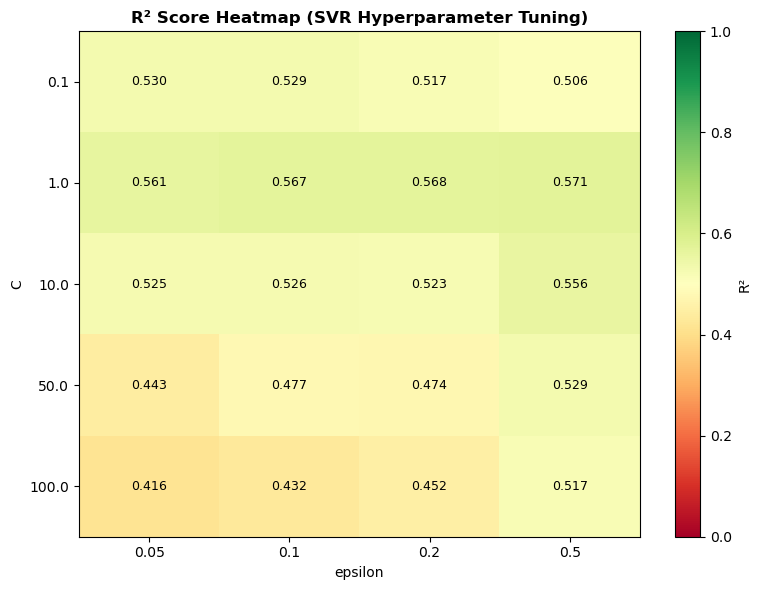

In [105]:
# Heatmap R² từ Grid Search
pivot_r2 = grid_df.pivot_table(values='R²', index='C', columns='epsilon')
plt.figure(figsize=(8, 6))
im = plt.imshow(pivot_r2.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.xticks(range(len(pivot_r2.columns)), pivot_r2.columns)
plt.yticks(range(len(pivot_r2.index)), pivot_r2.index)
plt.xlabel('epsilon')
plt.ylabel('C')
plt.title('R² Score Heatmap (SVR Hyperparameter Tuning)', fontweight='bold')
plt.colorbar(im, label='R²')
for i in range(len(pivot_r2.index)):
    for j in range(len(pivot_r2.columns)):
        plt.text(j, i, f'{pivot_r2.iloc[i, j]:.3f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()

The heatmap illustrates how different combinations of C and epsilon affect model performance.

The highest R² value observed is approximately 0.571, achieved at C = 1.0 and epsilon = 0.5.
For smaller epsilon values (e.g., 0.05–0.1), R² ranges from 0.529 to 0.567, indicating relatively stable performance.
When C increases to larger values (e.g., 50 or 100), performance decreases significantly, with R² dropping to around 0.416–0.529.

These results indicate that:

Moderate values of C provide the best balance between bias and variance.
Larger epsilon values smooth the model but may reduce sensitivity to data variations.

Overall, the SVR model is highly sensitive to hyperparameter selection, requiring careful tuning for optimal performance.

 Overall, the diagnostic plots confirm that although the SVR model achieves a moderate performance (R² = 0.5254), it struggles with extreme values and exhibits heteroscedastic error patterns. These limitations explain why SVR underperforms compared to tree-based models such as Decision Tree and Random Forest, which achieved higher R² scores (above 0.60).

### c)	Compare the advantages and disadvantages of SVM compared to other regression methods in terms of handling non-linear relationships, scalability, and interpretability for sales prediction. 
### Advantages of SVR

Despite not achieving the best performance, SVR still has several important advantages:

•	Ability to model non-linear relationships: Using the RBF kernel, SVR can capture complex, non-linear patterns in sales data, such as trends and lag effects. 
•	Robustness to noise: The epsilon-insensitive loss function allows SVR to ignore small errors, making it less sensitive to minor fluctuations in the data. 

•	Effective with proper preprocessing: When combined with feature scaling and transformations (such as log transformation used in this study), SVR can achieve stable and competitive performance.


### Disadvantages of SVR

However, SVR also has several limitations compared to models like Random Forest:

•	Lower predictive performance in this case: The results show that SVR underperforms compared to Random Forest, indicating limited ability to capture highly complex relationships in the dataset. 
•	High sensitivity to hyperparameters: The performance of SVR depends heavily on parameters such as C and epsilon. As observed in the experiments, different values lead to significant changes in performance, requiring extensive tuning. 

•	Poor scalability: SVR has higher computational complexity, making it less suitable for large datasets compared to Random Forest. 

•	Low interpretability: SVR is considered a black-box model, making it difficult to interpret the relationship between input features and predicted sales.

Overall, while SVR is a powerful method for modeling non-linear relationships, it is outperformed by Random Forest in this study. SVR remains a useful model when properly tuned and applied to moderately sized datasets, but for complex and large-scale sales prediction tasks, ensemble methods such as Random Forest may provide better performance and scalability.

# Question 5 

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [113]:
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['sales_lag_1'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].shift(1)
df['rolling_mean_3'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)
df['rolling_mean_7'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)
# Log transform target (giảm skewness)
df['unit_sales_log'] = np.log1p(df['unit_sales'])

# Xử lý NaN
df_clean = df.dropna(subset=['sales_lag_1', 'rolling_mean_3']).copy()

# Encode các biến categorical
le_family = LabelEncoder()
le_state = LabelEncoder()
le_type = LabelEncoder()

df_clean['family_encoded'] = le_family.fit_transform(df_clean['family'].astype(str))
df_clean['state_encoded'] = le_state.fit_transform(df_clean['state'].astype(str))
df_clean['store_type_encoded'] = le_type.fit_transform(df_clean['store_type'].astype(str))
# Encode các biến categorical
le_family = LabelEncoder()
le_state = LabelEncoder()
le_type = LabelEncoder()

df_clean['family_encoded'] = le_family.fit_transform(df_clean['family'].astype(str))
df_clean['state_encoded'] = le_state.fit_transform(df_clean['state'].astype(str))
df_clean['store_type_encoded'] = le_type.fit_transform(df_clean['store_type'].astype(str))

In [114]:
# 10 BIẾN X (THEO YÊU CẦU)
X = df_clean[[
    'cluster',           
    'store_nbr',        
    'day_of_week',      
    'is_weekend',      
    'sales_lag_1',       
    'rolling_mean_3',   
    'rolling_mean_7',    
    'perishable',        
    'family_encoded',   
    'state_encoded'      
]]

# Dùng LOG target
y = df_clean['unit_sales_log']

In [115]:
# CHIA TRAIN/TEST (THEO THỜI GIAN)
df_clean = df_clean.sort_values('date')
split_idx = int(len(df_clean) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\nTrain set: {len(X_train):,} dòng ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test):,} dòng ({len(X_test)/len(X)*100:.1f}%)")

configs = [
    {'name': 'Tree (max_depth=3)', 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'name': 'Tree (max_depth=5)', 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'name': 'Tree (max_depth=7)', 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'name': 'Tree (max_depth=10)', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'name': 'Tree (max_depth=5, min_samples_split=5)', 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1},
    {'name': 'Tree (max_depth=5, min_samples_split=10)', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 1},
    {'name': 'Tree (max_depth=5, min_samples_leaf=5)', 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 5},
    {'name': 'Tree (max_depth=5, min_samples_leaf=10)', 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 10},
]

tree_results = []


Train set: 3,751 dòng (80.0%)
Test set: 938 dòng (20.0%)


In [116]:

for config in configs:
    dt = DecisionTreeRegressor(
        max_depth=config['max_depth'],
        min_samples_split=config['min_samples_split'],
        min_samples_leaf=config['min_samples_leaf'],
        random_state=42
    )
    dt.fit(X_train, y_train)
    
    # Dự đoán và chuyển về scale gốc
    y_pred_log = dt.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test_orig, y_pred)
    
    tree_results.append({
        'Model': config['name'],
        'max_depth': config['max_depth'],
        'min_samples_split': config['min_samples_split'],
        'min_samples_leaf': config['min_samples_leaf'],
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f"{config['name']:<35} | MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")

Tree (max_depth=3)                  | MAE=2.3030 | RMSE=4.2003 | R²=0.5961
Tree (max_depth=5)                  | MAE=2.2474 | RMSE=4.1364 | R²=0.6083
Tree (max_depth=7)                  | MAE=2.3582 | RMSE=4.4933 | R²=0.5378
Tree (max_depth=10)                 | MAE=2.5885 | RMSE=5.0335 | R²=0.4200
Tree (max_depth=5, min_samples_split=5) | MAE=2.2474 | RMSE=4.1364 | R²=0.6083
Tree (max_depth=5, min_samples_split=10) | MAE=2.2474 | RMSE=4.1364 | R²=0.6083
Tree (max_depth=5, min_samples_leaf=5) | MAE=2.2474 | RMSE=4.1364 | R²=0.6083
Tree (max_depth=5, min_samples_leaf=10) | MAE=2.2474 | RMSE=4.1364 | R²=0.6083


In [117]:
# CHỌN MÔ HÌNH TỐT NHẤT
tree_results_df = pd.DataFrame(tree_results).sort_values('R²', ascending=False)
best_tree = tree_results_df.iloc[0]
print(f"{best_tree['Model']}")
print(f"max_depth={best_tree['max_depth']}, min_samples_split={best_tree['min_samples_split']}, min_samples_leaf={best_tree['min_samples_leaf']}")
print(f"MAE={best_tree['MAE']:.4f}")
print(f"RMSE={best_tree['RMSE']:.4f}")
print(f"R²={best_tree['R²']:.4f}")

Tree (max_depth=5)
max_depth=5, min_samples_split=2, min_samples_leaf=1
MAE=2.2474
RMSE=4.1364
R²=0.6083


The Decision Tree Regression model was trained using a maximum depth of 5, with min_samples_split = 2 and min_samples_leaf = 1. These hyperparameters play a critical role in controlling the complexity and generalization ability of the model.

Specifically, the parameter max_depth = 5 limits the depth of the tree, preventing it from becoming overly complex and reducing the risk of overfitting. Meanwhile, min_samples_split = 2 allows nodes to be split as long as there are at least two samples, enabling the model to fully explore possible data partitions. Similarly, min_samples_leaf = 1 ensures that leaf nodes can represent even small subsets of the data, allowing for more detailed modeling of patterns.

The trained model achieved a Mean Absolute Error (MAE) of 2.2474, a Root Mean Squared Error (RMSE) of 4.1364, and an R² score of 0.6083. These results indicate that the model is able to explain approximately 60.83% of the variance in the target variable, demonstrating strong predictive performance.

Overall, the selected hyperparameter configuration provides an effective balance between model complexity and generalization, allowing the Decision Tree to capture important non-linear relationships in the sales data while maintaining reasonable predictive accuracy.

In [124]:
best_dt = DecisionTreeRegressor(
    max_depth=int(best_tree['max_depth']),
    min_samples_split=int(best_tree['min_samples_split']),
    min_samples_leaf=int(best_tree['min_samples_leaf']),
    random_state=42
)
best_dt.fit(X_train, y_train)
y_pred_log = best_dt.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

In [126]:
# Câu b
# Lấy thông tin cây
n_nodes = best_dt.tree_.node_count
children_left = best_dt.tree_.children_left
children_right = best_dt.tree_.children_right
feature = best_dt.tree_.feature
threshold = best_dt.tree_.threshold
value = best_dt.tree_.value
n_node_samples = best_dt.tree_.n_node_samples
print(f"Tổng số node: {n_nodes}")
print(f"Độ sâu: {best_dt.get_depth()}")
print(f"Số lá: {best_dt.get_n_leaves()}")

Tổng số node: 63
Độ sâu: 5
Số lá: 32


In [128]:
# 1. INTERNAL SPLIT 
root_node = 0
root_feature_idx = feature[root_node]
root_feature_name = X.columns[root_feature_idx]
root_threshold = threshold[root_node]
root_samples = n_node_samples[root_node]
root_value = np.expm1(value[root_node][0][0])  # Chuyển về scale gốc
root_impurity = best_dt.tree_.impurity[root_node]

# Giải thích ý nghĩa của biến
def get_feature_meaning(feature_name):
    meanings = {
        'sales_lag_1': 'Doanh số ngày hôm trước',
        'rolling_mean_3': 'Trung bình động 3 ngày (xu hướng ngắn hạn)',
        'rolling_mean_7': 'Trung bình động 7 ngày (xu hướng trung hạn)',
        'day_of_week': 'Ngày trong tuần (0=Thứ 2, 6=Chủ nhật)',
        'is_weekend': 'Cờ cuối tuần (1=Thứ 7/Chủ nhật)',
        'cluster': 'Cụm cửa hàng',
        'store_nbr': 'Mã số cửa hàng',
        'perishable': 'Sản phẩm dễ hỏng (1=có, 0=không)',
        'family_encoded': 'Nhóm sản phẩm',
        'state_encoded': 'Tỉnh/Thành phố'
    }
    return meanings.get(feature_name, feature_name)

In [130]:
# Tìm node lá có số mẫu nhiều nhất
leaf_nodes = [i for i in range(n_nodes) if children_left[i] == children_right[i]]
leaf_with_most_samples = max(leaf_nodes, key=lambda i: n_node_samples[i])

leaf_samples = n_node_samples[leaf_with_most_samples]
leaf_value = np.expm1(value[leaf_with_most_samples][0][0])  # Chuyển về scale gốc
leaf_impurity = best_dt.tree_.impurity[leaf_with_most_samples]

In [132]:
print(f"""
ROOT NODE:
Branching variation: {root_feature_name}
Meaning of the variable: {get_feature_meaning(root_feature_name)}
Branching threshold: {root_threshold:.4f}
Number of samples at the node: {root_samples:,}
Average predicted value: {root_value:.4f} unit_sales
MSE: {root_impurity:.4f}
""")


ROOT NODE:
Branching variation: rolling_mean_3
Meaning of the variable: Trung bình động 3 ngày (xu hướng ngắn hạn)
Branching threshold: 11.7152
Number of samples at the node: 3,751
Average predicted value: 4.3645 unit_sales
MSE: 0.6512



In [134]:
print(f"""
THE SIGNIFICANCE OF THIS BRANCH:
   → At the root node, the algorithm selects the variable. {root_feature_name} ({get_feature_meaning(root_feature_name)}) 
     This is the most important factor for branching.
   
   → LEFT BRANCH: If {root_feature_name} ≤ {root_threshold:.4f}
     * The products have {get_feature_meaning(root_feature_name)} short
     * Lower projected sales
     * This is a slow-selling product group
   
  → RIGHT BRANCH: If {root_feature_name} > {root_threshold:.4f}
   * The products include {get_feature_meaning(root_feature_name)} High
   * Higher projected sales
   * This is a best-selling product group
""")


THE SIGNIFICANCE OF THIS BRANCH:
   → At the root node, the algorithm selects the variable. rolling_mean_3 (Trung bình động 3 ngày (xu hướng ngắn hạn)) 
     This is the most important factor for branching.
   
   → LEFT BRANCH: If rolling_mean_3 ≤ 11.7152
     * The products have Trung bình động 3 ngày (xu hướng ngắn hạn) short
     * Lower projected sales
     * This is a slow-selling product group
   
  → RIGHT BRANCH: If rolling_mean_3 > 11.7152
   * The products include Trung bình động 3 ngày (xu hướng ngắn hạn) High
   * Higher projected sales
   * This is a best-selling product group



In [136]:
# Tìm đường đi đến node lá
def get_path_to_node(node_id):
    path = []
    current = node_id
    while current != 0:
        parent = None
        for i in range(n_nodes):
            if children_left[i] == current or children_right[i] == current:
                parent = i
                break
        if parent is None:
            break
        is_left = (children_left[parent] == current)
        path.append((parent, is_left))
        current = parent
    return list(reversed(path))

path = get_path_to_node(leaf_with_most_samples)

In [138]:
# Mô tả đường đi
def describe_path():
    conditions = []
    for node_id, is_left in path:
        feat_idx = feature[node_id]
        feat_name = X.columns[feat_idx]
        thres = threshold[node_id]
        direction = "≤" if is_left else ">"
        if feat_name == 'rolling_mean_3':
            if direction == '≤':
                conditions.append(f"doanh số trung bình 3 ngày ≤ {thres:.2f}")
            else:
                conditions.append(f"doanh số trung bình 3 ngày > {thres:.2f}")
        elif feat_name == 'day_of_week':
            if direction == '≤':
                conditions.append(f"ngày trong tuần ≤ {thres:.0f} (đầu tuần)")
            else:
                conditions.append(f"ngày trong tuần > {thres:.0f} (cuối tuần)")
        elif feat_name == 'is_weekend':
            conditions.append("cuối tuần" if direction == '>' else "ngày thường")
        else:
            conditions.append(f"{feat_name} {direction} {thres:.2f}")
    return " và ".join(conditions)

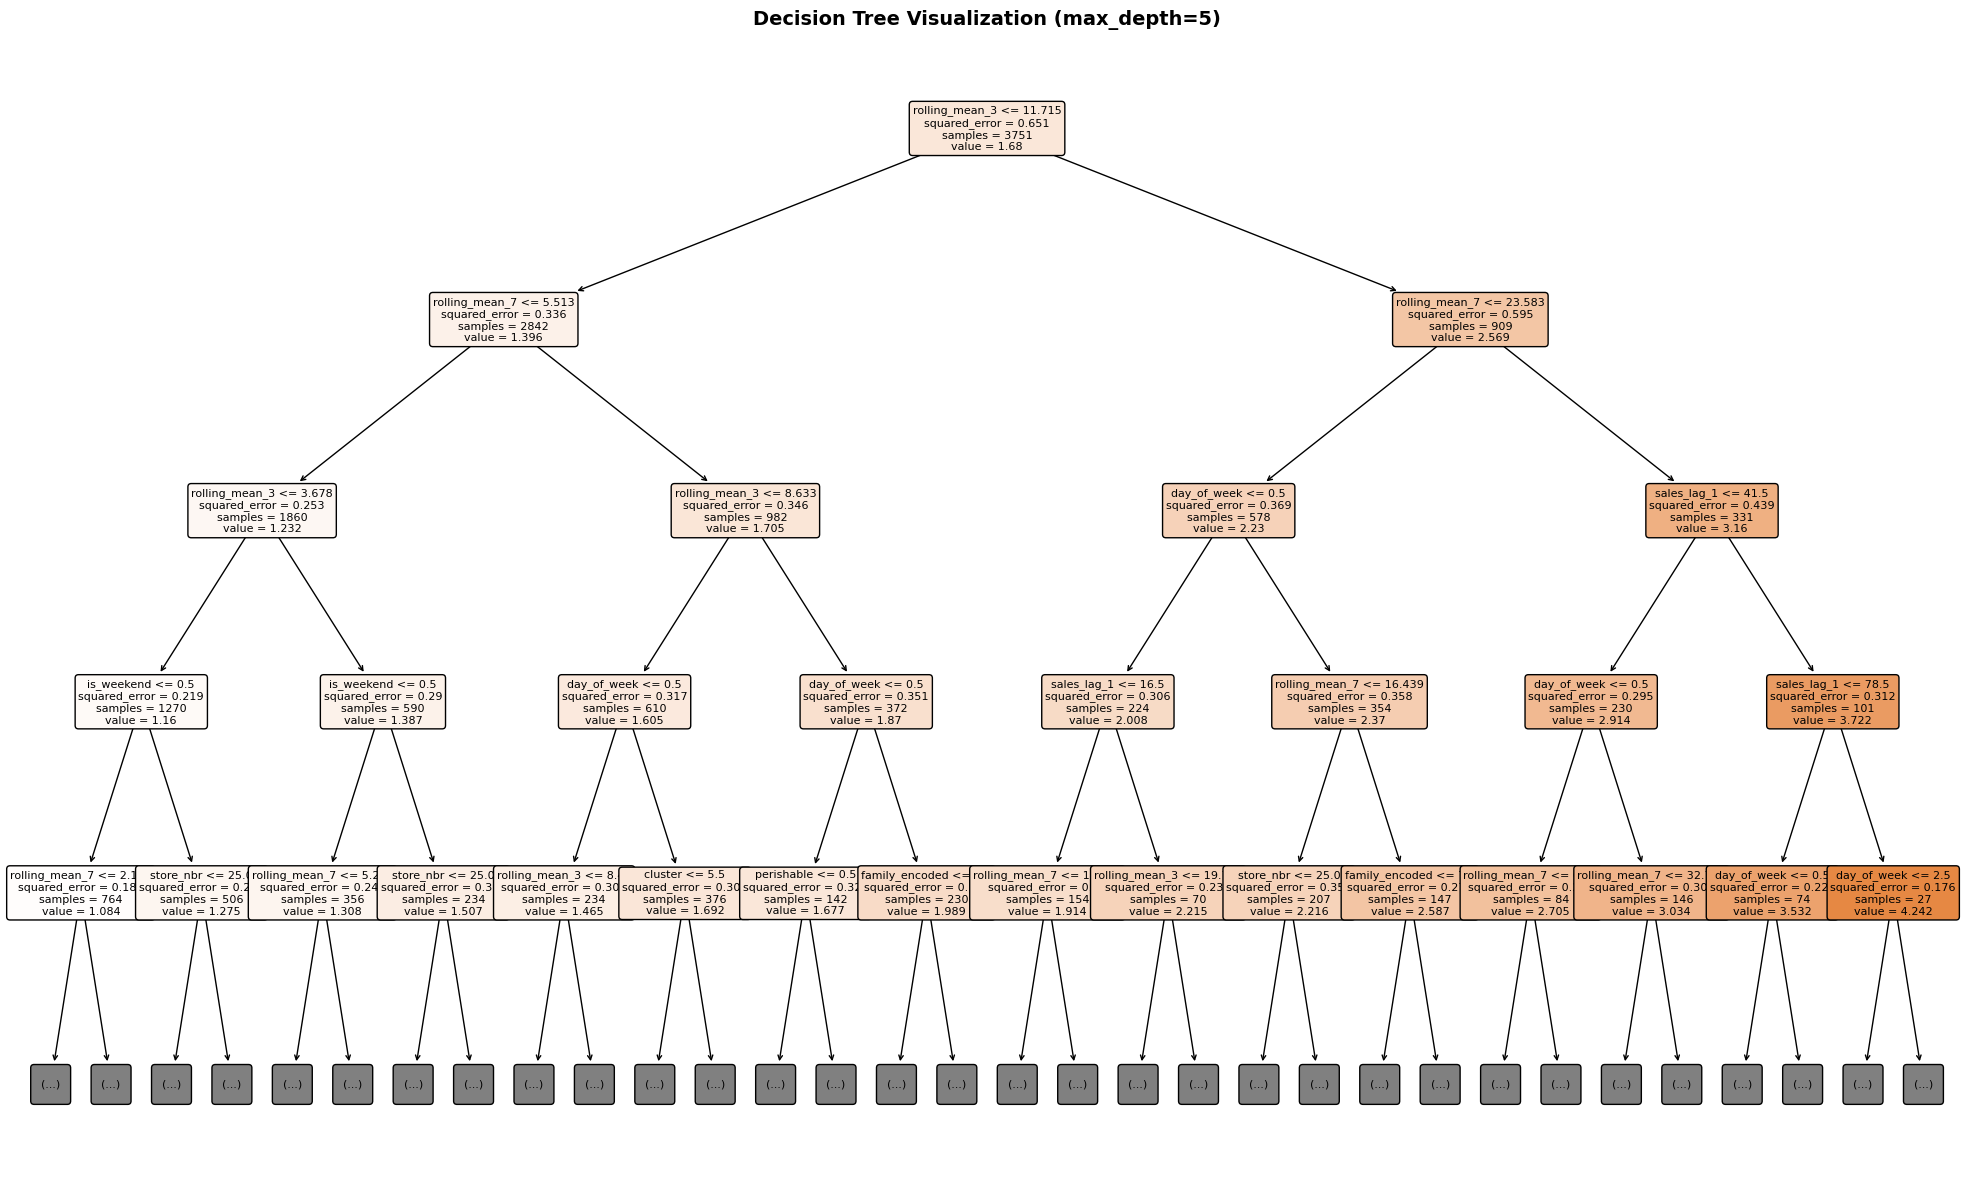

In [140]:
plt.figure(figsize=(20, 12))
plot_tree(
    best_dt,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title(f"Decision Tree Visualization (max_depth={best_dt.get_depth()})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [141]:
print(f"""
  • Biến phân nhánh: {root_feature_name} ({get_feature_meaning(root_feature_name)})          
  • Ngưỡng phân nhánh: {root_threshold:.4f}                                                  
  • Số mẫu tại node: {root_samples:,}                                                         
 Ý NGHĨA:                                                                                    
  → Nếu {root_feature_name} ≤ {root_threshold:.4f}: Nhóm sản phẩm có doanh số thấp           
 → Nếu {root_feature_name} > {root_threshold:.4f}: Nhóm sản phẩm có doanh số cao            
  → Đây là yếu tố quan trọng nhất để phân biệt sản phẩm bán chạy và bán chậm                 

                                                                                              
  • Số mẫu: {leaf_samples:,}                                                                  
  • Giá trị dự đoán: {leaf_value:.4f} unit_sales                                              
                                                                                             
  ĐƯỜNG ĐI ({len(path)} BƯỚC):                                                                
""")


  • Biến phân nhánh: rolling_mean_3 (Trung bình động 3 ngày (xu hướng ngắn hạn))          
  • Ngưỡng phân nhánh: 11.7152                                                  
  • Số mẫu tại node: 3,751                                                         
 Ý NGHĨA:                                                                                    
  → Nếu rolling_mean_3 ≤ 11.7152: Nhóm sản phẩm có doanh số thấp           
 → Nếu rolling_mean_3 > 11.7152: Nhóm sản phẩm có doanh số cao            
  → Đây là yếu tố quan trọng nhất để phân biệt sản phẩm bán chạy và bán chậm                 

                                                                                              
  • Số mẫu: 385                                                                  
  • Giá trị dự đoán: 2.1331 unit_sales                                              
                                                                                             
  ĐƯỜNG ĐI (5 BƯỚC):                           

In [142]:
for i, (node_id, is_left) in enumerate(path, 1):
    feat_idx = feature[node_id]
    feat_name = X.columns[feat_idx]
    thres = threshold[node_id]
    direction = "≤" if is_left else ">"
    print(f"  {i}. {feat_name} {direction} {thres:.4f}")

print(f"""
  Ý NGHĨA KINH DOANH:
  → Các sản phẩm thỏa mãn {len(path)} điều kiện trên có doanh số rất thấp
  → Đây là nhóm sản phẩm cần được quan tâm đẩy mạnh bán hàng
  → Dự đoán doanh số: {leaf_value:.4f} đơn vị/ngày
""")                                                                   

  1. rolling_mean_3 ≤ 11.7152
  2. rolling_mean_7 ≤ 5.5132
  3. rolling_mean_3 ≤ 3.6780
  4. is_weekend ≤ 0.5000
  5. rolling_mean_7 > 2.1060

  Ý NGHĨA KINH DOANH:
  → Các sản phẩm thỏa mãn 5 điều kiện trên có doanh số rất thấp
  → Đây là nhóm sản phẩm cần được quan tâm đẩy mạnh bán hàng
  → Dự đoán doanh số: 2.1331 đơn vị/ngày



One terminal node in the tree corresponds to a combination of conditions involving rolling averages and weekend indicators.

Observations that satisfy these conditions are predicted to have very low expected sales, with an average prediction of approximately 2.13 units.

From a business perspective, this group represents slow-moving products during weekdays, suggesting that these products may require promotions or marketing strategies to increase demand.

In [144]:
# câu c
def get_business_meaning(path, X, threshold, feature):
    """Mô tả ý nghĩa kinh doanh của node lá"""
    conditions = []
    for node_id, is_left in path:
        feat_idx = feature[node_id]
        feat_name = X.columns[feat_idx]
        thres = threshold[node_id]
        direction = "≤" if is_left else ">"
        
        if feat_name == 'rolling_mean_3':
            if direction == '≤':
                conditions.append(f"doanh số trung bình 3 ngày không quá {thres:.2f}")
            else:
                conditions.append(f"doanh số trung bình 3 ngày trên {thres:.2f}")
        elif feat_name == 'day_of_week':
            if direction == '≤':
                if thres == 4:
                    conditions.append("ngày đầu tuần (Thứ 2-5)")
                else:
                    conditions.append(f"ngày ≤ {thres:.0f}")
            else:
                conditions.append(f"ngày > {thres:.0f}")
        elif feat_name == 'is_weekend':
            conditions.append("cuối tuần" if (direction == '>' and thres == 0.5) else "ngày thường")
        else:
            conditions.append(f"{feat_name} {direction} {thres:.2f}")
    
    return " và ".join(conditions)

# Gán vào self
self = type('obj', (object,), {'_get_business_meaning': get_business_meaning})()

In [145]:
# Tính feature importance
feature_importance = best_dt.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("RANKING 10 VARIABLES BY IMPORTANCE:")
print("-"*55)
for i, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"{row['Feature']:<20} | {row['Importance']:.4f} {bar}")

print(f"KẾT LUẬN FEATURE IMPORTANCE:")
print(f"   • BIẾN QUAN TRỌNG NHẤT: {importance_df.iloc[0]['Feature']} (Importance = {importance_df.iloc[0]['Importance']:.4f})")
print(f"   • BIẾN QUAN TRỌNG THỨ 2: {importance_df.iloc[1]['Feature']} (Importance = {importance_df.iloc[1]['Importance']:.4f})")
print(f"   • BIẾN QUAN TRỌNG THỨ 3: {importance_df.iloc[2]['Feature']} (Importance = {importance_df.iloc[2]['Importance']:.4f})")

print(f"\n   → {importance_df.iloc[0]['Feature']}  has the greatest impact on sales.")
print(f"   → {importance_df.iloc[1]['Feature']} is the second most important variable")
print(f"   → Variables with importance = 0 are not used in decision trees.")

RANKING 10 VARIABLES BY IMPORTANCE:
-------------------------------------------------------
rolling_mean_3       | 0.6658 █████████████████████████████████
rolling_mean_7       | 0.2390 ███████████
sales_lag_1          | 0.0406 ██
day_of_week          | 0.0293 █
is_weekend           | 0.0113 
store_nbr            | 0.0075 
family_encoded       | 0.0030 
cluster              | 0.0024 
perishable           | 0.0012 
state_encoded        | 0.0000 
KẾT LUẬN FEATURE IMPORTANCE:
   • BIẾN QUAN TRỌNG NHẤT: rolling_mean_3 (Importance = 0.6658)
   • BIẾN QUAN TRỌNG THỨ 2: rolling_mean_7 (Importance = 0.2390)
   • BIẾN QUAN TRỌNG THỨ 3: sales_lag_1 (Importance = 0.0406)

   → rolling_mean_3  has the greatest impact on sales.
   → rolling_mean_7 is the second most important variable
   → Variables with importance = 0 are not used in decision trees.


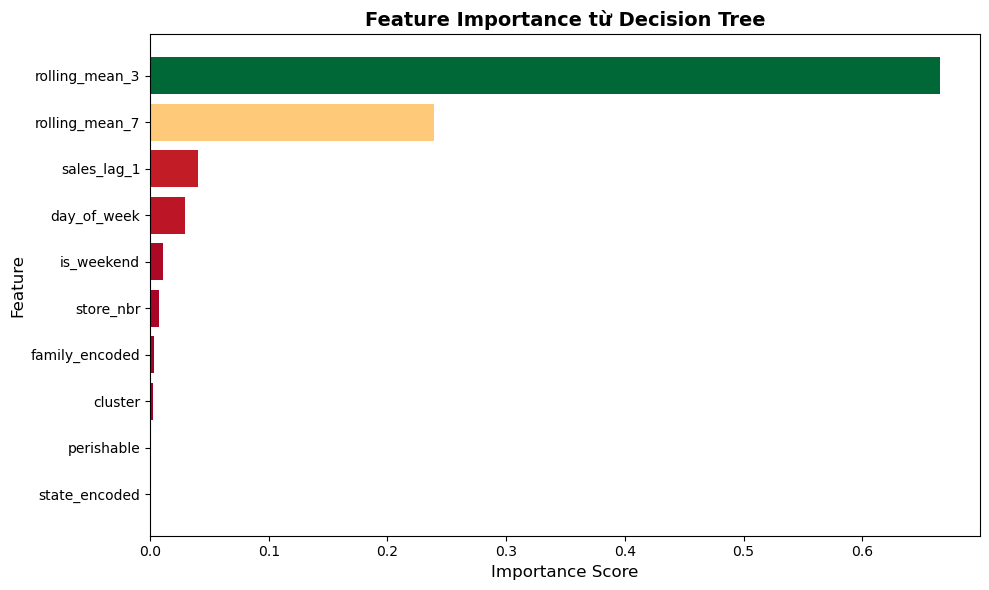

In [146]:
# VẼ BIỂU ĐỒ FEATURE IMPORTANCE
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(importance_df['Importance'] / importance_df['Importance'].max())
plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance từ Decision Tree', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

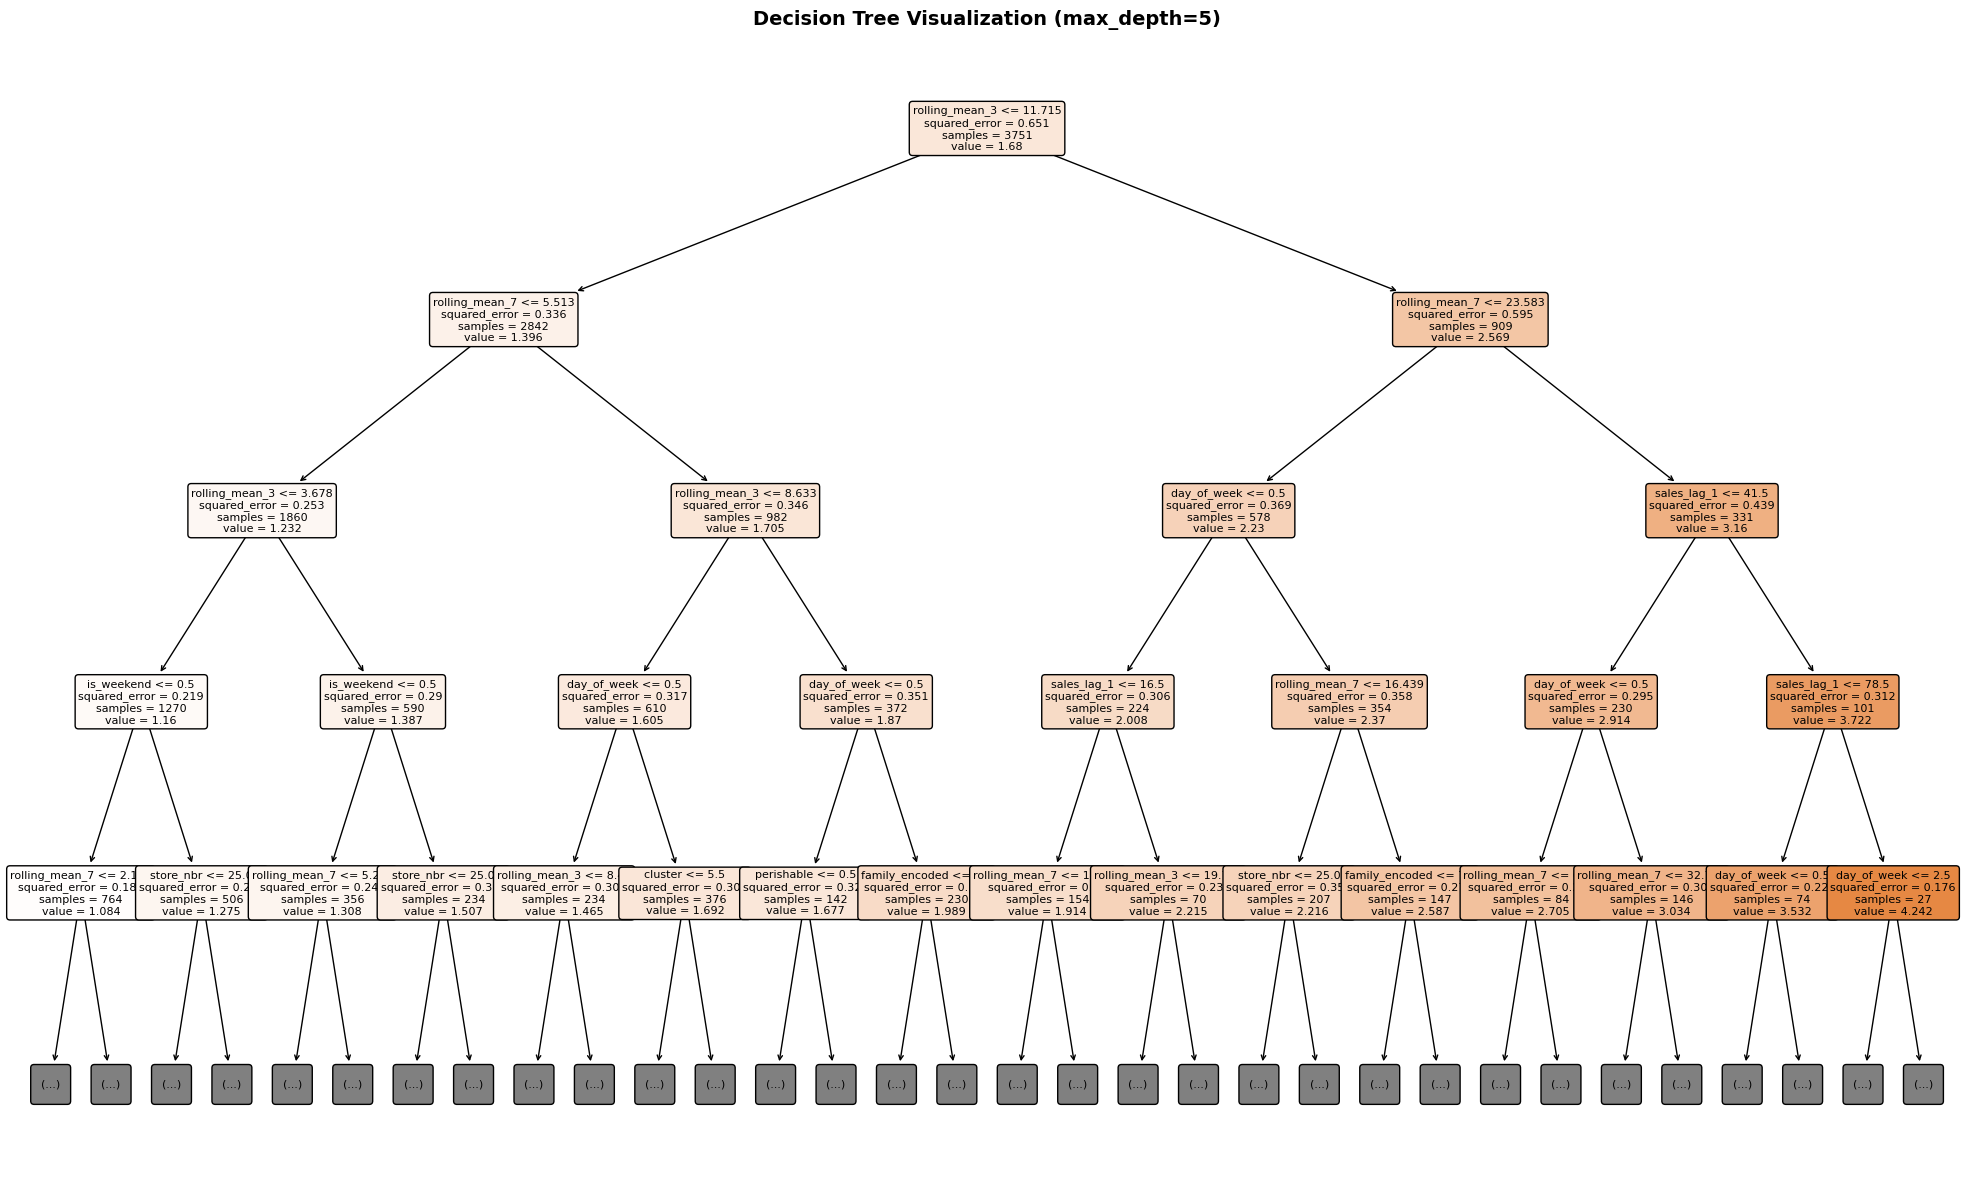

In [147]:
# VẼ CÂY QUYẾT ĐỊNH
plt.figure(figsize=(20, 12))
plot_tree(
    best_dt,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title(f"Decision Tree Visualization (max_depth={best_dt.get_depth()})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [155]:
# SO SÁNH VỚI CÁC MÔ HÌNH KHÁC
# Chuyển target về scale gốc để đánh giá
y_test_orig = np.expm1(y_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr_log = lr.predict(X_test)
y_pred_lr = np.expm1(y_pred_lr_log)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf_log = rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_log)

# SVR
svr = SVR(kernel='rbf', C=10, epsilon=0.1)
svr.fit(X_train, y_train)
y_pred_svr_log = svr.predict(X_test)
y_pred_svr = np.expm1(y_pred_svr_log)

# Decision Tree (đã có y_pred_best từ trước)
y_pred_dt = np.expm1(best_dt.predict(X_test))

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR'],
    'MAE': [
        mean_absolute_error(y_test_orig, y_pred_lr),
        mean_absolute_error(y_test_orig, y_pred_dt),
        mean_absolute_error(y_test_orig, y_pred_rf),
        mean_absolute_error(y_test_orig, y_pred_svr)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_orig, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test_orig, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test_orig, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test_orig, y_pred_svr))
    ],
    'R²': [
        r2_score(y_test_orig, y_pred_lr),
        r2_score(y_test_orig, y_pred_dt),
        r2_score(y_test_orig, y_pred_rf),
        r2_score(y_test_orig, y_pred_svr)
    ],
    'Interpretability': ['Cao', 'Rất cao', 'Trung bình', 'Thấp']
}).sort_values('R²', ascending=False)

print(comparison.round(4).to_string(index=False))

            Model    MAE   RMSE     R² Interpretability
    Decision Tree 2.2474 4.1364 0.6083          Rất cao
    Random Forest 2.2469 4.1453 0.6066       Trung bình
              SVR 2.2489 4.1653 0.6028             Thấp
Linear Regression 2.7426 5.2996 0.3570              Cao


In [157]:
# So sánh Decision Tree với mô hình tốt nhất
best_model = comparison.loc[comparison['R²'].idxmax()]
dt_model = comparison[comparison['Model'] == 'Decision Tree'].iloc[0]
print(f"""
NHẬN XÉT:
   • Decision Tree đạt R² = {dt_model['R²']:.4f}
   • Mô hình tốt nhất là {best_model['Model']} với R² = {best_model['R²']:.4f}
""")


NHẬN XÉT:
   • Decision Tree đạt R² = 0.6083
   • Mô hình tốt nhất là Decision Tree với R² = 0.6083



**Model Recommendation:**

Based on the comparison results, the Decision Tree model achieved the highest R² score (0.6083) among all evaluated models.

In addition to good predictive accuracy, Decision Trees offer high interpretability, allowing managers to easily understand the decision rules used by the model. This transparency is particularly valuable in business applications such as sales forecasting.

Therefore, the Decision Tree model is recommended for practical deployment, as it provides a strong balance between predictive accuracy and interpretability.